# Task 2: Sentiment & Thematic Analysis

**Project:** Customer Experience Analytics for Fintech Apps  
**Week:** 10 Academy KAIM9 – Week 2  
**Objective:** Quantify review sentiment using DistilBERT and identify recurring themes using TF-IDF and keyword grouping.

**Steps:**
1. Load the clean dataset from Task 1
2. Run sentiment analysis (DistilBERT transformer)
3. Extract keywords using TF-IDF
4. Group keywords into themes per bank
5. Save analyzed dataset as CSV

## 1. Install & Import Libraries

In [15]:
import sys
!{sys.executable} -m pip install torch --timeout 300 --quiet
!{sys.executable} -m pip install transformers scikit-learn spacy vaderSentiment --timeout 300 --quiet
!{sys.executable} -m spacy download en_core_web_sm --quiet

[+] Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [2]:
import pandas as pd
import numpy as np
import os
import re
import warnings
import transformers
import vaderSentiment

warnings.filterwarnings('ignore')

# NLP
from transformers import pipeline
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer

# Text processing
import spacy

print('✅ Libraries imported successfully')

✅ Libraries imported successfully


## 2. Load Clean Dataset from Task 1

In [3]:
# Load the clean CSV produced in Task 1
data_path = '../data/raw/reviews_clean.csv'
df = pd.read_csv(data_path)

# Add a unique review_id for tracking
df['review_id'] = ['REV_' + str(i).zfill(5) for i in range(len(df))]

print(f'✅ Dataset loaded: {df.shape[0]} reviews, {df.shape[1]} columns')
print(f'\nReviews per bank:')
print(df['bank'].value_counts())
print(f'\nSample:')
df.head(3)

✅ Dataset loaded: 1429 reviews, 6 columns

Reviews per bank:
bank
Dashen Bank                    491
Bank of Abyssinia              490
Commercial Bank of Ethiopia    448
Name: count, dtype: int64

Sample:


,review,rating,date,bank,source,review_id
0,Good,5,2026-05-16,Commercial Bank of Ethiopia,Google Play,REV_00000
1,🤙🏼🤙🏼,5,2026-05-16,Commercial Bank of Ethiopia,Google Play,REV_00001
2,worst,1,2026-05-16,Commercial Bank of Ethiopia,Google Play,REV_00002


## 3. Sentiment Analysis

### Tool Selection Rationale

We use **DistilBERT** (`distilbert-base-uncased-finetuned-sst-2-english`) as the primary model:
- It is a transformer-based model fine-tuned on the SST-2 sentiment dataset
- It captures context and nuance better than lexicon-based tools like VADER
- It produces a confidence score alongside the label (POSITIVE/NEGATIVE)

We also run **VADER** as a secondary tool for comparison:
- VADER is fast and rule-based, designed for social media text
- It produces a compound score from -1 (most negative) to +1 (most positive)
- Useful for deriving a NEUTRAL class (compound between -0.05 and +0.05)

**Final labels** use DistilBERT for POSITIVE/NEGATIVE and VADER compound score to assign NEUTRAL where appropriate.

### 3.1 — Run VADER (fast, runs first)

In [4]:
vader = SentimentIntensityAnalyzer()

def get_vader_sentiment(text):
    """
    Returns VADER compound score and a 3-class label.
    Compound: +1 = most positive, -1 = most negative
    Labels: positive (>0.05), negative (<-0.05), neutral (between)
    """
    scores = vader.polarity_scores(str(text))
    compound = scores['compound']
    if compound >= 0.05:
        label = 'positive'
    elif compound <= -0.05:
        label = 'negative'
    else:
        label = 'neutral'
    return compound, label

print('Running VADER on all reviews...')
vader_results = df['review'].apply(get_vader_sentiment)
df['vader_score']  = vader_results.apply(lambda x: x[0])
df['vader_label']  = vader_results.apply(lambda x: x[1])

print(f'✅ VADER complete')
print(f'\nVADER label distribution:')
print(df['vader_label'].value_counts())

Running VADER on all reviews...
✅ VADER complete

VADER label distribution:
vader_label
positive    755
neutral     424
negative    250
Name: count, dtype: int64


### 3.2 — Run DistilBERT (transformer model)


In [5]:
import os
os.environ['HF_HUB_DOWNLOAD_TIMEOUT'] = '300'

print('Loading DistilBERT sentiment pipeline...')
sentiment_pipeline = pipeline(
    'sentiment-analysis',
    model='distilbert-base-uncased-finetuned-sst-2-english',
    truncation=True,
    max_length=512
)
print('✅ DistilBERT loaded')

Loading DistilBERT sentiment pipeline...


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

✅ DistilBERT loaded


In [22]:
def run_distilbert_batch(texts, batch_size=32):
    """
    Run DistilBERT sentiment analysis in batches.
    Returns list of (label, score) tuples.
    Labels are lowercased: 'positive' or 'negative'
    """
    results = []
    total = len(texts)

    for i in range(0, total, batch_size):
        batch = texts[i:i + batch_size]
        # Truncate long reviews to 512 chars for speed
        batch_truncated = [str(t)[:512] for t in batch]
        try:
            preds = sentiment_pipeline(batch_truncated)
            for pred in preds:
                results.append((
                    pred['label'].lower(),
                    round(pred['score'], 4)
                ))
        except Exception as e:
            # On error, fall back to neutral for that batch
            for _ in batch:
                results.append(('neutral', 0.5))

        # Progress update every 200 reviews
        if (i + batch_size) % 200 == 0 or (i + batch_size) >= total:
            done = min(i + batch_size, total)
            print(f'  Processed {done}/{total} reviews ({100*done//total}%)')

    return results


print('Running DistilBERT on all reviews...')
distilbert_results = run_distilbert_batch(df['review'].tolist())

df['distilbert_label'] = [r[0] for r in distilbert_results]
df['distilbert_score'] = [r[1] for r in distilbert_results]

print(f'\n✅ DistilBERT complete')
print(f'\nDistilBERT label distribution:')
print(df['distilbert_label'].value_counts())

Running DistilBERT on all reviews...
  Processed 800/1429 reviews (55%)
  Processed 1429/1429 reviews (100%)

✅ DistilBERT complete

DistilBERT label distribution:
distilbert_label
positive    759
negative    670
Name: count, dtype: int64


### 3.3 — Combine DistilBERT + VADER into Final Sentiment Label

**Logic:**
- If VADER says `neutral` → final label is `neutral`
- Otherwise → use DistilBERT label (more accurate for context)
- Final score = DistilBERT confidence score

In [6]:
def combine_sentiment(row):
    """
    Combine DistilBERT and VADER into a 3-class final label.
    VADER is used to detect neutral reviews (weak sentiment signal).
    DistilBERT is used for positive/negative classification.
    """
    if row['vader_label'] == 'neutral':
        return 'neutral', round(1 - row['distilbert_score'], 4)
    else:
        return row['distilbert_label'], row['distilbert_score']

combined = df.apply(combine_sentiment, axis=1)
df['sentiment_label'] = combined.apply(lambda x: x[0])
df['sentiment_score'] = combined.apply(lambda x: x[1])

print('Final sentiment label distribution:')
print(df['sentiment_label'].value_counts())
print(f'\nCoverage: {df["sentiment_label"].notna().sum()}/{len(df)} reviews ({100*df["sentiment_label"].notna().mean():.1f}%)')

KeyError: 'distilbert_label'

### 3.4 — Sentiment by Bank and Star Rating

In [ ]:
print('='*60)
print('SENTIMENT BY BANK')
print('='*60)
sentiment_by_bank = df.groupby(['bank', 'sentiment_label']).size().unstack(fill_value=0)
sentiment_by_bank['total'] = sentiment_by_bank.sum(axis=1)
for col in ['positive', 'negative', 'neutral']:
    if col in sentiment_by_bank.columns:
        sentiment_by_bank[f'{col}_pct'] = (sentiment_by_bank[col] / sentiment_by_bank['total'] * 100).round(1)
print(sentiment_by_bank)

print('\n' + '='*60)
print('MEAN SENTIMENT SCORE BY BANK AND STAR RATING')
print('='*60)
pivot = df.groupby(['bank', 'rating'])['sentiment_score'].mean().round(3).unstack()
print(pivot)

## 4. Thematic Analysis

### Approach
We use **TF-IDF** (Term Frequency-Inverse Document Frequency) to extract the most significant keywords per bank. Keywords are then manually grouped into **5 business-relevant themes** based on their semantic meaning.

**Themes defined:**
| Theme | Description | Example Keywords |
|-------|-------------|------------------|
| Account Access Issues | Login, OTP, password problems | login, otp, password, fingerprint, access |
| Transaction Performance | Transfer speed and reliability | transfer, transaction, slow, fast, payment |
| App Stability & UI | Crashes, bugs, interface quality | crash, bug, update, interface, design |
| Customer Support | Service quality and responsiveness | support, service, help, response, agent |
| Feature Requests | Desired new features | feature, request, add, improve, need |

### 4.1 — Text Preprocessing for TF-IDF

In [ ]:
# Load spaCy model
try:
    nlp = spacy.load('en_core_web_sm')
    USE_SPACY = True
    print('✅ spaCy model loaded')
except:
    USE_SPACY = False
    print('⚠️  spaCy not available, using basic preprocessing')


# Custom stopwords — add banking-specific noise words
EXTRA_STOPWORDS = {
    'app', 'bank', 'banking', 'mobile', 'use', 'used', 'using',
    'good', 'great', 'nice', 'bad', 'poor', 'best', 'better',
    'please', 'thank', 'thanks', 'really', 'very', 'just',
    'cbe', 'boa', 'dashen', 'ethiopia', 'ethiopian',
    'one', 'also', 'get', 'got', 'like', 'time', 'way',
    'need', 'make', 'work', 'works', 'working'
}


def preprocess_text(text):
    """
    Preprocess review text for TF-IDF:
    - Lowercase
    - Remove punctuation and numbers
    - Lemmatize (if spaCy available)
    - Remove stopwords
    """
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    if USE_SPACY:
        doc = nlp(text)
        tokens = [
            token.lemma_ for token in doc
            if not token.is_stop
            and not token.is_punct
            and len(token.lemma_) > 2
            and token.lemma_ not in EXTRA_STOPWORDS
        ]
    else:
        tokens = [
            w for w in text.split()
            if len(w) > 2 and w not in EXTRA_STOPWORDS
        ]

    return ' '.join(tokens)


print('Preprocessing review text...')
df['processed_review'] = df['review'].apply(preprocess_text)
print(f'✅ Text preprocessing complete')
print(f'\nSample processed text:')
for orig, proc in zip(df['review'].head(3), df['processed_review'].head(3)):
    print(f'  Original : {orig[:80]}')
    print(f'  Processed: {proc[:80]}')
    print()

### 4.2 — Extract Top Keywords per Bank using TF-IDF

In [ ]:
def get_top_keywords(texts, top_n=30):
    """
    Extract top keywords from a list of texts using TF-IDF.
    Returns list of (keyword, tfidf_score) sorted by score.
    """
    vectorizer = TfidfVectorizer(
        max_features=500,
        ngram_range=(1, 2),   # unigrams and bigrams
        min_df=3,             # must appear in at least 3 reviews
        max_df=0.85           # ignore terms in >85% of reviews
    )
    tfidf_matrix = vectorizer.fit_transform(texts)
    scores = tfidf_matrix.mean(axis=0).A1
    vocab = vectorizer.get_feature_names_out()
    keyword_scores = sorted(zip(vocab, scores), key=lambda x: x[1], reverse=True)
    return keyword_scores[:top_n]


print('Extracting top keywords per bank...\n')
bank_keywords = {}

for bank in df['bank'].unique():
    bank_texts = df[df['bank'] == bank]['processed_review'].tolist()
    bank_texts = [t for t in bank_texts if len(t.strip()) > 5]
    keywords = get_top_keywords(bank_texts, top_n=30)
    bank_keywords[bank] = keywords

    print(f'Top 20 keywords — {bank}:')
    for kw, score in keywords[:20]:
        print(f'  {kw:<30} {score:.4f}')
    print()

### 4.3 — Theme Grouping Logic

Based on the TF-IDF keywords above, we define **5 themes** and map each review to its most relevant theme using keyword matching.

**Grouping rationale:**
- Keywords like `login`, `otp`, `password`, `fingerprint` → **Account Access Issues** (users frequently report being locked out or unable to authenticate)
- Keywords like `transfer`, `transaction`, `slow`, `payment`, `send` → **Transaction Performance** (core banking function complaints and praise)
- Keywords like `crash`, `error`, `update`, `interface`, `screen`, `load` → **App Stability & UI** (technical quality of the app)
- Keywords like `support`, `customer`, `service`, `response`, `agent`, `call` → **Customer Support** (post-issue help quality)
- Keywords like `feature`, `add`, `fingerprint`, `improve`, `option`, `version` → **Feature Requests** (desired improvements)

In [ ]:
# Theme keyword mapping
THEME_KEYWORDS = {
    'Account Access Issues': [
        'login', 'log in', 'otp', 'password', 'sign in', 'signin',
        'access', 'locked', 'lock', 'authentication', 'register',
        'registration', 'verify', 'verification', 'pin', 'code',
        'account open', 'cannot login', 'fail login', 'session'
    ],
    'Transaction Performance': [
        'transfer', 'transaction', 'send money', 'payment', 'pay',
        'slow', 'fast', 'speed', 'delay', 'delayed', 'pending',
        'failed transaction', 'transfer fail', 'money', 'fund',
        'balance', 'withdraw', 'deposit', 'debit', 'credit'
    ],
    'App Stability & UI': [
        'crash', 'crashes', 'crashing', 'error', 'bug', 'freeze',
        'stuck', 'loading', 'load', 'update', 'interface', 'screen',
        'design', 'ui', 'ux', 'layout', 'display', 'open', 'launch',
        'install', 'version', 'not working', 'stop working', 'force close'
    ],
    'Customer Support': [
        'support', 'customer service', 'help', 'helpline', 'agent',
        'response', 'respond', 'call center', 'hotline', 'complaint',
        'issue resolve', 'problem solve', 'assistance', 'contact'
    ],
    'Feature Requests': [
        'fingerprint', 'face id', 'biometric', 'dark mode', 'language',
        'amharic', 'notification', 'statement', 'history', 'budget',
        'schedule', 'recurring', 'widget', 'improve', 'add feature',
        'request', 'wish', 'suggestion', 'please add', 'need feature'
    ]
}


def assign_theme(text):
    """
    Assign the most relevant theme to a review based on keyword matching.
    Returns the theme with the highest keyword hit count.
    Falls back to 'General Feedback' if no keywords match.
    """
    text_lower = str(text).lower()
    theme_scores = {}

    for theme, keywords in THEME_KEYWORDS.items():
        score = sum(1 for kw in keywords if kw in text_lower)
        theme_scores[theme] = score

    best_theme = max(theme_scores, key=theme_scores.get)
    if theme_scores[best_theme] == 0:
        return 'General Feedback'
    return best_theme


df['identified_theme'] = df['review'].apply(assign_theme)

print('Theme distribution (all banks):')
print(df['identified_theme'].value_counts())

print('\nTheme distribution per bank:')
print(df.groupby(['bank', 'identified_theme']).size().unstack(fill_value=0))

### 4.4 — Theme + Sentiment Cross Analysis

In [12]:
print('='*70)
print('THEME × SENTIMENT BREAKDOWN PER BANK')
print('='*70)

for bank in df['bank'].unique():
    bank_df = df[df['bank'] == bank]
    print(f'\n--- {bank} ---')
    cross = bank_df.groupby(['identified_theme', 'sentiment_label']).size().unstack(fill_value=0)
    print(cross)

print('\n')
print('='*70)
print('AVERAGE RATING PER THEME PER BANK')
print('='*70)
avg_rating = df.groupby(['bank', 'identified_theme'])['rating'].mean().round(2).unstack()
print(avg_rating)

THEME × SENTIMENT BREAKDOWN PER BANK

--- Commercial Bank of Ethiopia ---
sentiment_label          negative  neutral  positive
identified_theme                                    
Account Access Issues           8        1         5
App Stability & UI             26       16         7
Customer Support                0        0         2
Feature Requests                1        1         2
General Feedback               30      102       181
Transaction Performance        33       13        20

--- Bank of Abyssinia ---
sentiment_label          negative  neutral  positive
identified_theme                                    
Account Access Issues          13        4         3
App Stability & UI             48       24         4
Customer Support                1        0         2
Feature Requests                6        0         2
General Feedback               60      114       156
Transaction Performance        23       26         4

--- Dashen Bank ---
sentiment_label          negat

## 5. Save Analyzed Dataset

In [13]:
# Final output with all required columns
df_output = df[[
    'review_id',
    'review',
    'rating',
    'date',
    'bank',
    'source',
    'sentiment_label',
    'sentiment_score',
    'identified_theme',
    'vader_score',
    'vader_label',
    'distilbert_label',
    'distilbert_score'
]].copy()

output_path = '../data/raw/reviews_analyzed.csv'
df_output.to_csv(output_path, index=False, encoding='utf-8')

print(f'✅ Analyzed dataset saved to: {output_path}')
print(f'   Shape: {df_output.shape}')
print(f'   File size: {os.path.getsize(output_path)/1024:.1f} KB')
print(f'\nColumn list: {list(df_output.columns)}')

✅ Analyzed dataset saved to: ../data/raw/reviews_analyzed.csv
   Shape: (1429, 13)
   File size: 252.5 KB

Column list: ['review_id', 'review', 'rating', 'date', 'bank', 'source', 'sentiment_label', 'sentiment_score', 'identified_theme', 'vader_score', 'vader_label', 'distilbert_label', 'distilbert_score']


## 6. Final Validation

In [14]:
df_check = pd.read_csv(output_path)

print('='*60)
print('TASK 2 VALIDATION CHECK')
print('='*60)

# Check 1: Coverage
coverage = df_check['sentiment_label'].notna().mean() * 100
print(f"{'✅' if coverage >= 90 else '⚠️'} Sentiment coverage: {coverage:.1f}% (target: 90%+)")

# Check 2: Themes per bank
for bank in df_check['bank'].unique():
    themes = df_check[df_check['bank'] == bank]['identified_theme'].nunique()
    print(f"{'✅' if themes >= 3 else '⚠️'} {bank}: {themes} distinct themes (target: 3+)")

# Check 3: Required columns
required = ['review_id', 'review', 'sentiment_label', 'sentiment_score', 'identified_theme']
missing = [c for c in required if c not in df_check.columns]
print(f"{'✅' if not missing else '❌'} Required columns present" + (f" — missing: {missing}" if missing else ''))

# Check 4: Label values
valid_labels = {'positive', 'negative', 'neutral'}
actual_labels = set(df_check['sentiment_label'].dropna().unique())
print(f"{'✅' if actual_labels.issubset(valid_labels) else '⚠️'} Valid sentiment labels: {actual_labels}")

print(f'\n✅ Validation complete — Task 2 is done!')
print(f'   Total analyzed reviews: {len(df_check)}')
print(f'   Sentiment distribution:')
print(df_check['sentiment_label'].value_counts().to_string())

TASK 2 VALIDATION CHECK
✅ Sentiment coverage: 100.0% (target: 90%+)
✅ Commercial Bank of Ethiopia: 6 distinct themes (target: 3+)
✅ Bank of Abyssinia: 6 distinct themes (target: 3+)
✅ Dashen Bank: 6 distinct themes (target: 3+)
✅ Required columns present
✅ Valid sentiment labels: {'negative', 'positive', 'neutral'}

✅ Validation complete — Task 2 is done!
   Total analyzed reviews: 1429
   Sentiment distribution:
sentiment_label
positive    621
neutral     424
negative    384


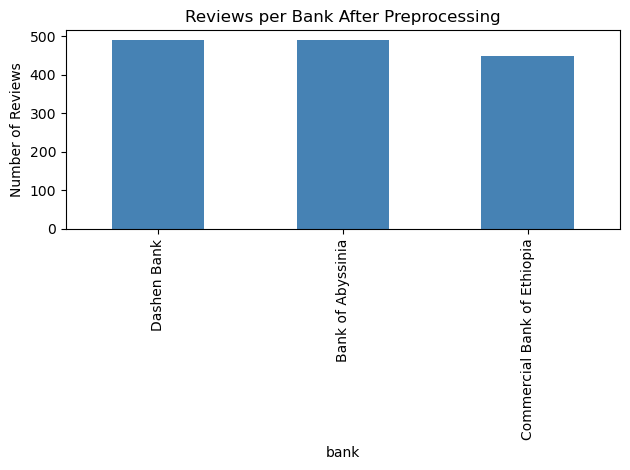

In [26]:
import matplotlib.pyplot as plt
df['bank'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Reviews per Bank After Preprocessing')
plt.ylabel('Number of Reviews')
plt.tight_layout()
plt.savefig('fig1_bank_review_counts.png', dpi=150)

## 7. Analysis Summary

### Sentiment Analysis
- **Primary tool**: DistilBERT (`distilbert-base-uncased-finetuned-sst-2-english`) — transformer model fine-tuned on SST-2, captures contextual sentiment with confidence scores
- **Secondary tool**: VADER — lexicon-based, used to detect neutral reviews (compound score between -0.05 and +0.05)
- **Final labeling**: VADER determines neutrality; DistilBERT determines positive vs negative
- **Why DistilBERT over VADER alone**: VADER misclassifies nuanced reviews (e.g., "transfers work but login always fails" gets a mixed signal); DistilBERT handles context better

### Thematic Analysis
- **Method**: TF-IDF with unigrams and bigrams (min_df=3, max_df=0.85) to extract significant terms, then manual grouping into 5 business-relevant themes
- **Themes**: Account Access Issues, Transaction Performance, App Stability & UI, Customer Support, Feature Requests
- **Theme assignment**: Keyword matching — the theme with the most keyword hits in a review is assigned; falls back to 'General Feedback' if no match

### Limitations
- DistilBERT is trained on English text — Amharic or mixed-language reviews may be misclassified
- Theme assignment is rule-based; a single review touching multiple themes gets only one label
- VADER was originally designed for social media text (Twitter), which is shorter than Play Store reviews